# 01 · Análisis Exploratorio de Datos
**TFM — Streaming Analytics para Supply Chain | Telecomunicaciones Multi-País**

Autora: Iliana Yazmin Pasos Gallo

---

Este notebook cubre el análisis exploratorio previo a la fase de limpieza y modelado.

| Sección | Contenido |
|---|---|
| **0** | Imports y configuración |
| **1** | Carga de archivos fuente |
| **2** | Exploración general |
| **3** | Calidad de catálogos — nulos e imputación |
| **4** | Análisis multi-país |
| **5** | Estacionalidad semanal |
| **6** | Correlación inventario vs ventas |
| **7** | Top SKUs — análisis Pareto |
| **8** | Revisión de PRECIO_UNITARIO |
| **9** | Conclusiones |

**Entradas:** `../data/raw/Datos_{PAIS}.csv`, `../data/catalogs/Bodega_{PAIS}.csv`, `../data/catalogs/Devices_{PAIS}.csv`

**Salidas:** gráficas en `../outputs/dashboard/`


## 0 · Imports y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import sys
sys.path.append('../')
from config import PAISES, PARAMS

warnings.filterwarnings('ignore')

# -- Estilo de graficas -------------------------------------------------------
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor'  : '#1a1d27',
    'axes.edgecolor'  : '#3a3d4d',
    'axes.labelcolor' : '#e0e0e0',
    'xtick.color'     : '#a0a0b0',
    'ytick.color'     : '#a0a0b0',
    'text.color'      : '#e0e0e0',
    'grid.color'      : '#2a2d3d',
    'grid.linestyle'  : '--',
    'font.family'     : 'DejaVu Sans',
    'font.size'       : 11,
})

PALETTE = ['#00d4aa', '#6c63ff', '#ff6b6b', '#ffd166', '#4ecdc4', '#a29bfe']

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

print('Librerias cargadas correctamente.')


Librerias cargadas correctamente.


## 1 · Carga de Archivos Fuente

In [2]:
# -- Carga y concatena todos los paises disponibles --------------------------
dfs_datos, dfs_bodega, dfs_devices = [], [], []

for pais in PAISES:
    d = pd.read_csv(
        f'../data/raw/Datos_{pais}.csv',
        sep=',',
        engine='python',
        quotechar='"'
    )
    b = pd.read_csv(f'../data/catalogs/Bodega_{pais}.csv')
    v = pd.read_csv(f'../data/catalogs/Devices_{pais}.csv')
    dfs_datos.append(d)
    dfs_bodega.append(b)
    dfs_devices.append(v)

datos   = pd.concat(dfs_datos,   ignore_index=True)
bodega  = pd.concat(dfs_bodega,  ignore_index=True)
devices = pd.concat(dfs_devices, ignore_index=True)

print(f'Paises cargados : {PAISES}')
print(f'Datos   -- {datos.shape[0]:>6} filas x {datos.shape[1]} columnas')
print(f'Bodega  -- {bodega.shape[0]:>6} filas x {bodega.shape[1]} columnas')
print(f'Devices -- {devices.shape[0]:>6} filas x {devices.shape[1]} columnas')


Paises cargados : ['PY', 'NI']
Datos   -- 4322592 filas x 9 columnas
Bodega  --    617 filas x 5 columnas
Devices --   2470 filas x 8 columnas


## 2 · Exploración General

In [3]:
datos.head(5)


,PAIS,FECHA_VENTA_INVENTARIO,ANOMES,TIPO_TRANSACCION,CODIGO_SKU,CODIGO_BODEGA,VALUE,COSTO,DELIVERY_DATE
0,PY,20230102,202301,SALES,CO017A,28,2,129.0,NaN
1,PY,20230102,202301,SALES,CO017A,19,9,129.0,NaN
2,PY,20230102,202301,SALES,CO017A,82,2,129.0,NaN
3,PY,20230102,202301,SALES,CO017A,91,1,129.0,NaN
4,PY,20230102,202301,SALES,CO017A,92,5,129.0,NaN


In [4]:
print('Tipos de datos')
print(datos.dtypes)
print()
print('Estadisticas descriptivas')
datos.describe(include='all')


Tipos de datos
PAIS                       object
FECHA_VENTA_INVENTARIO      int64
ANOMES                      int64
TIPO_TRANSACCION           object
CODIGO_SKU                 object
CODIGO_BODEGA              object
VALUE                       int64
COSTO                     float64
DELIVERY_DATE             float64
dtype: object

Estadisticas descriptivas


,PAIS,FECHA_VENTA_INVENTARIO,ANOMES,TIPO_TRANSACCION,CODIGO_SKU,CODIGO_BODEGA,VALUE,COSTO,DELIVERY_DATE
count,4322592,4.322592e+06,4.322592e+06,4322592,4322592.0,4322071.0,4.322592e+06,4.280187e+06,2078582.0
unique,2,NaN,NaN,3,813.0,340.0,NaN,NaN,NaN
top,PY,NaN,NaN,INVENTORY,3075.0,1937.0,NaN,NaN,NaN
freq,2244010,NaN,NaN,3097893,96197.0,149240.0,NaN,NaN,NaN
mean,NaN,2.024100e+07,2.024099e+05,NaN,NaN,NaN,6.675240e+00,1.913035e+02,20260417.0
std,NaN,7.967961e+03,7.967909e+01,NaN,NaN,NaN,5.082063e+01,2.777648e+02,0.0
min,NaN,2.023010e+07,2.023010e+05,NaN,NaN,NaN,1.000000e+00,0.000000e+00,20260417.0
25%,NaN,2.023112e+07,2.023110e+05,NaN,NaN,NaN,1.000000e+00,4.158000e+01,20260417.0
50%,NaN,2.024072e+07,2.024070e+05,NaN,NaN,NaN,2.000000e+00,9.775000e+01,20260417.0
75%,NaN,2.025033e+07,2.025030e+05,NaN,NaN,NaN,4.000000e+00,1.891200e+02,20260417.0


### 2.1 Duplicados y nulos

In [5]:
datos_agg = (
    datos
    .groupby([
        'FECHA_VENTA_INVENTARIO',
        'CODIGO_SKU',
        'CODIGO_BODEGA',
        'TIPO_TRANSACCION'
    ])
    .agg({
        'VALUE': 'sum',
        'COSTO': 'mean'
    })
    .reset_index()
)


In [6]:
print(f'Registros duplicados: {datos_agg.duplicated().sum()}')
print()
nulos = datos.isnull().sum().rename('nulos')
pct   = (nulos / len(datos) * 100).rename('%')
resumen_nulos = pd.concat([nulos, pct], axis=1)
resumen_nulos[resumen_nulos['nulos'] > 0]


Registros duplicados: 0



,nulos,%
CODIGO_BODEGA,521,0.012053
COSTO,42405,0.981009
DELIVERY_DATE,2244010,51.913528


### 2.2 Tipo de transaccion

In [7]:
tipos_utiles = ['SALES', 'INVENTORY', 'TRANSITS']

datos_filtrados = datos[datos['TIPO_TRANSACCION'].isin(tipos_utiles)].copy()


In [8]:
tx_counts = datos_filtrados['TIPO_TRANSACCION'].value_counts()


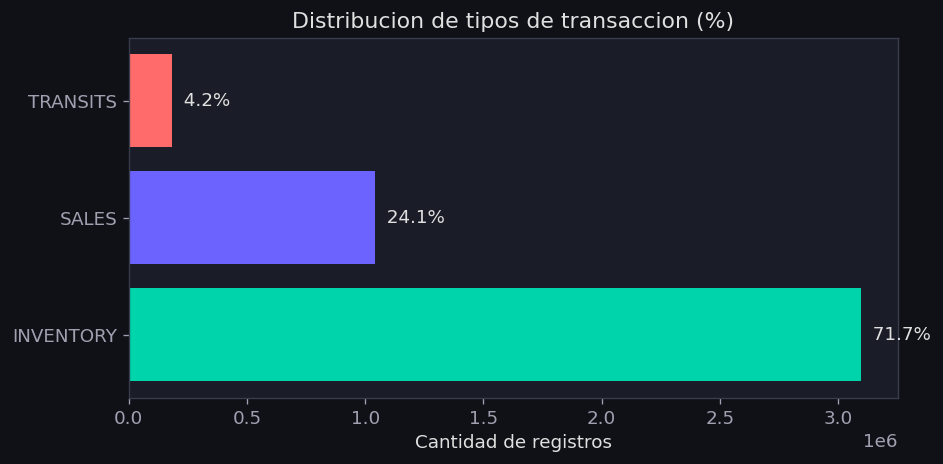

In [9]:
total = tx_counts.sum()
percentages = (tx_counts / total * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    tx_counts.index,
    tx_counts.values,
    color=PALETTE[:len(tx_counts)]
)

for i, (value, pct) in enumerate(zip(tx_counts.values, percentages)):
    ax.text(value, i, f'  {pct}%', va='center')

ax.set_title('Distribucion de tipos de transaccion (%)')
ax.set_xlabel('Cantidad de registros')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../outputs/dashboard/dist_tipo_transaccion_barh.png', bbox_inches='tight')
plt.show()


In [10]:
datos_filtrados['TIPO_TRANSACCION'].value_counts(normalize=True) * 100


TIPO_TRANSACCION
INVENTORY    71.667486
SALES        24.093761
TRANSITS      4.238753
Name: proportion, dtype: float64

### 2.3 Distribucion de VALUE y COSTO

In [11]:
datos_filtrados['VALUE'].value_counts().sort_index().head(20)


VALUE
1     2078181
2      642982
3      358458
4      257158
5      211704
6      118707
7       85229
8       69642
9       50567
10      69178
11      28531
12      28375
13      22014
14      22088
15      24239
16      13800
17      11250
18      12495
19      11629
20      20279
Name: count, dtype: int64

In [12]:
print(
    datos_filtrados
    .groupby('TIPO_TRANSACCION')['VALUE']
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
)


                      count      mean        std  min  50%   90%   95%    99%  \
TIPO_TRANSACCION                                                                
INVENTORY         3097893.0  8.683393  59.850671  1.0  2.0  13.0  24.0  100.0   
SALES             1041475.0  1.127412   1.630611  1.0  1.0   1.0   1.0    3.0   
TRANSITS           183224.0  4.256773  10.117576  1.0  2.0   7.0  10.0   30.0   

                      max  
TIPO_TRANSACCION           
INVENTORY         12000.0  
SALES               318.0  
TRANSITS            520.0  


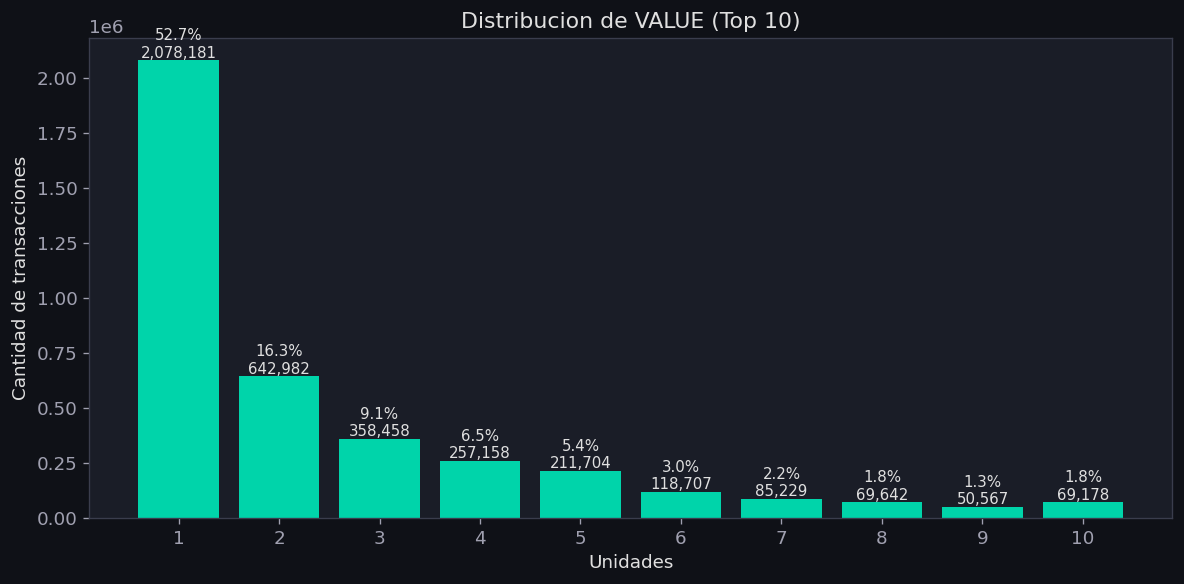

In [13]:
# -- Distribucion VALUE top 10 -----------------------------------------------
vc    = datos_filtrados['VALUE'].value_counts().sort_index().head(10)
total = vc.sum()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(vc)), vc.values, color=PALETTE[0])

for i, v in enumerate(vc):
    porcentaje = (v / total) * 100
    ax.text(i, v, f'{porcentaje:.1f}%\n{v:,}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(range(len(vc)))
ax.set_xticklabels(vc.index)
ax.set_title('Distribucion de VALUE (Top 10)')
ax.set_xlabel('Unidades')
ax.set_ylabel('Cantidad de transacciones')
plt.tight_layout()
plt.savefig('../outputs/dashboard/value_distribution_bar.png', dpi=300, bbox_inches='tight')
plt.show()


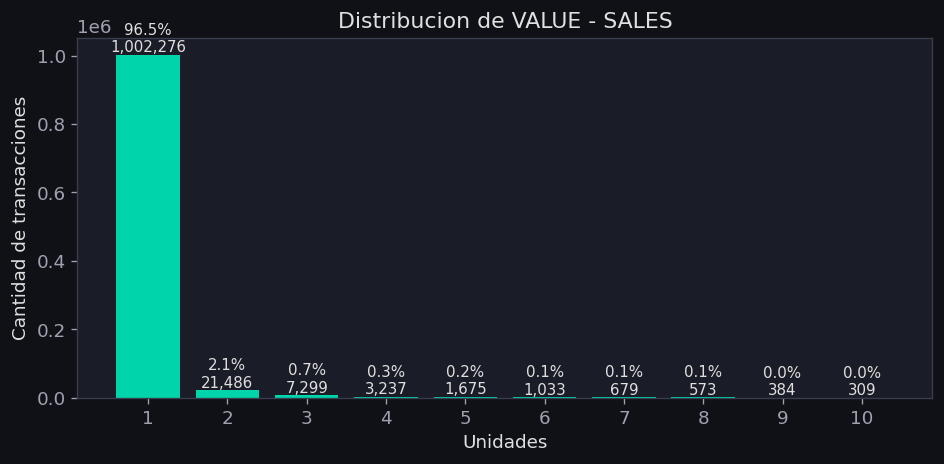

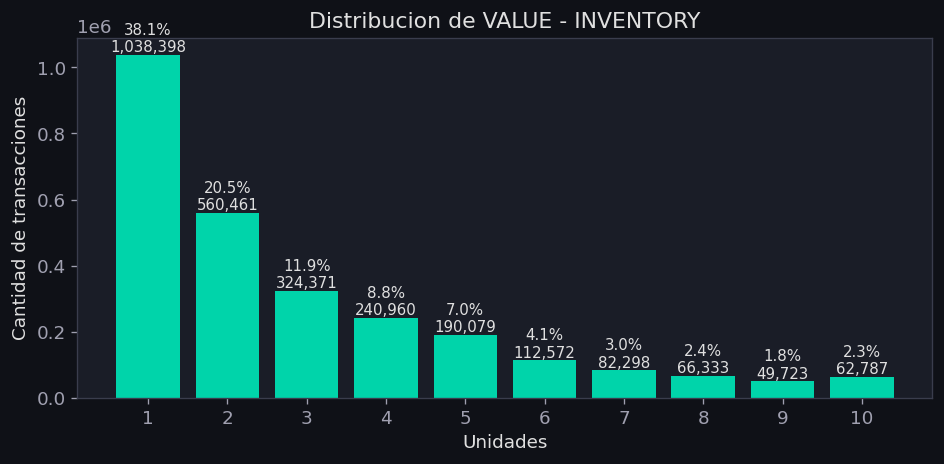

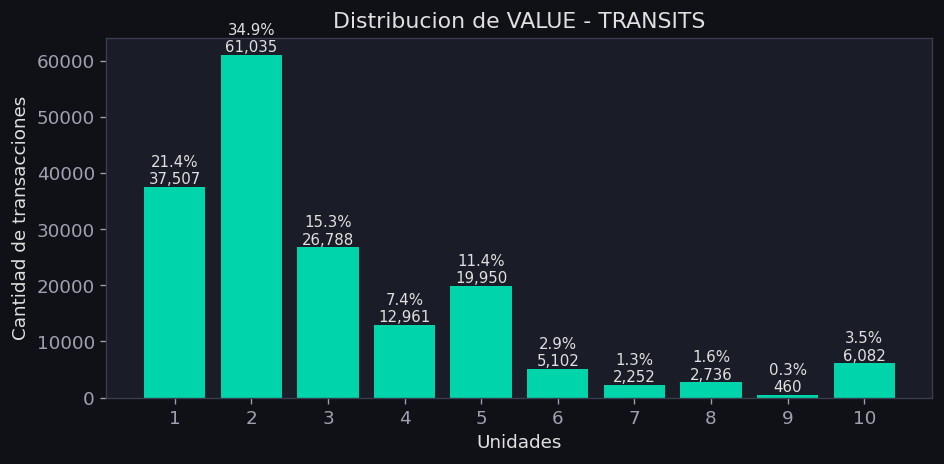

In [14]:
# -- Distribucion VALUE por tipo de transaccion -------------------------------
for tipo in datos_filtrados['TIPO_TRANSACCION'].unique():
    df_tipo = datos_filtrados[datos_filtrados['TIPO_TRANSACCION'] == tipo]
    vc    = df_tipo['VALUE'].value_counts().sort_index().head(10)
    total = vc.sum()

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(range(len(vc)), vc.values, color=PALETTE[0])

    for i, v in enumerate(vc):
        porcentaje = (v / total) * 100
        ax.text(i, v, f'{porcentaje:.1f}%\n{v:,}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index)
    ax.set_title(f'Distribucion de VALUE - {tipo}')
    ax.set_xlabel('Unidades')
    ax.set_ylabel('Cantidad de transacciones')
    plt.tight_layout()
    plt.savefig(f'../outputs/dashboard/value_distribution_{tipo}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [15]:
datos_filtrados['COSTO'].value_counts().sort_index().head(20)


COSTO
0.00     37
0.03    267
0.04    537
0.05    963
0.06    999
0.07    570
0.08    232
0.09    276
0.10    289
0.11    280
0.12    329
0.13    273
0.14    533
0.15    421
0.16    183
0.17    351
0.18    240
0.19    156
0.20    286
0.21    564
Name: count, dtype: int64

In [16]:
# -- PRECIO_UNITARIO calculado como COSTO / VALUE ----------------------------
datos_filtrados['PRECIO_UNITARIO'] = datos_filtrados['COSTO'] / datos_filtrados['VALUE']


In [17]:
resumen_costo = (
    datos_filtrados
    .groupby('TIPO_TRANSACCION')['COSTO']
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    .round(2)
)
print(resumen_costo)


                      count    mean     std   min     50%     90%      95%  \
TIPO_TRANSACCION                                                             
INVENTORY         3056255.0  215.74  292.45  0.00  103.71  667.82   976.84   
SALES             1041475.0  104.20  194.31  0.00   46.99  215.25   384.12   
TRANSITS           182457.0  279.25  317.40  0.15  140.07  840.00  1050.06   

                      99%      max  
TIPO_TRANSACCION                    
INVENTORY         1283.28  2149.45  
SALES             1171.75  2149.45  
TRANSITS          1360.44  2149.45  


In [18]:
print(
    datos_filtrados[datos_filtrados['PRECIO_UNITARIO'] == 0]
    .groupby('TIPO_TRANSACCION')
    .size()
)


TIPO_TRANSACCION
INVENTORY    31
SALES         6
dtype: int64


In [19]:
# -- Filtrar registros invalidos ----------------------------------------------
datos_filtrados = datos_filtrados[
    (datos_filtrados['PRECIO_UNITARIO'] > 1) &
    (datos_filtrados['VALUE'] > 0)
]


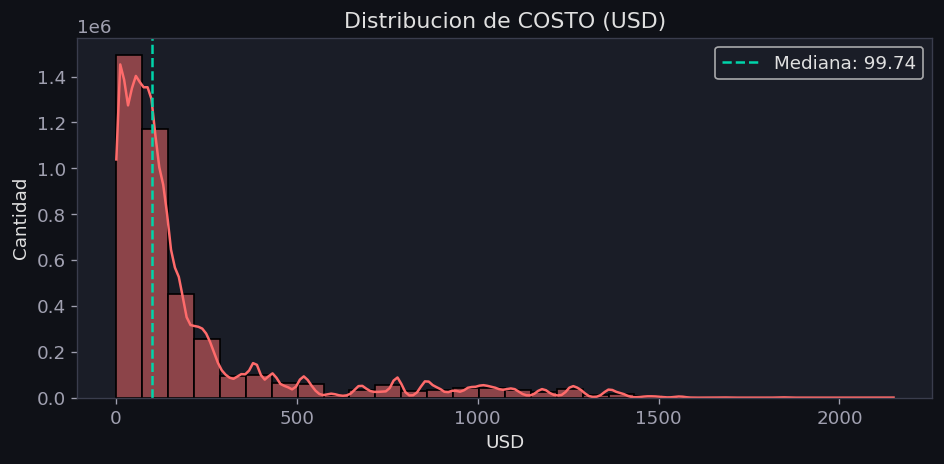

COSTO -- media: 200.6 | mediana: 99.74 | max: 2149.45


In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(datos_filtrados['COSTO'], bins=30, kde=True, ax=ax, color=PALETTE[2])
mediana = datos_filtrados['COSTO'].median()
ax.axvline(mediana, color=PALETTE[0], linestyle='--', label=f'Mediana: {mediana:.2f}')
ax.set_title('Distribucion de COSTO (USD)')
ax.set_xlabel('USD')
ax.set_ylabel('Cantidad')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/dashboard/eda_costo.png', dpi=300, bbox_inches='tight')
plt.show()
print('COSTO -- media:', round(datos_filtrados['COSTO'].mean(), 1),
      '| mediana:', mediana,
      '| max:', datos_filtrados['COSTO'].max())


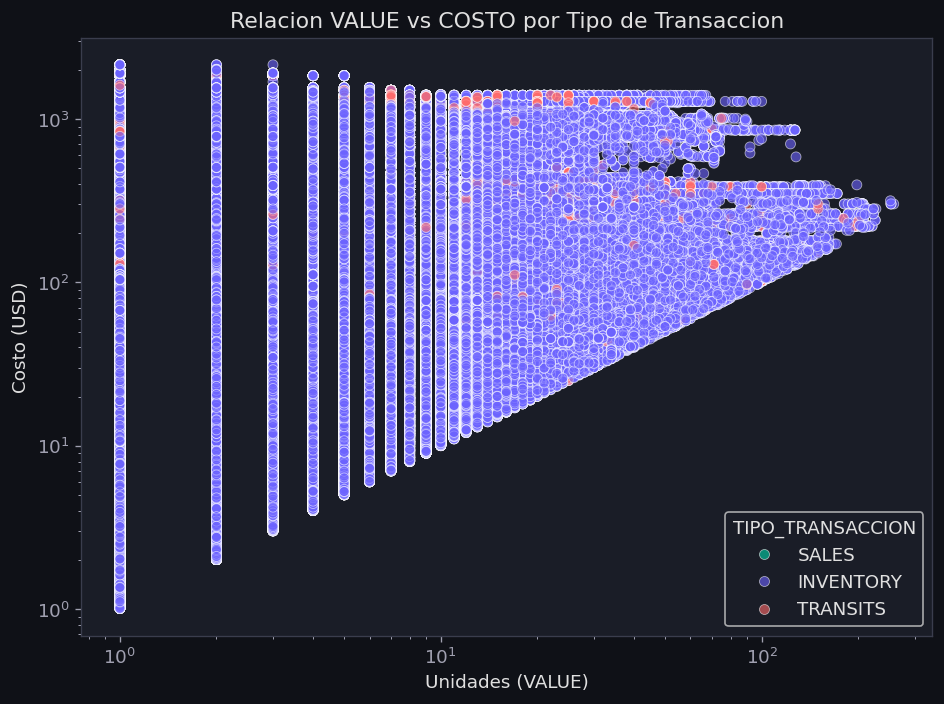

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=datos_filtrados,
    x='VALUE', y='COSTO',
    hue='TIPO_TRANSACCION',
    palette=PALETTE[:3],
    alpha=0.6, ax=ax
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Relacion VALUE vs COSTO por Tipo de Transaccion')
ax.set_xlabel('Unidades (VALUE)')
ax.set_ylabel('Costo (USD)')
plt.tight_layout()
plt.savefig('../outputs/dashboard/value_vs_costo.png', dpi=300, bbox_inches='tight')
plt.show()


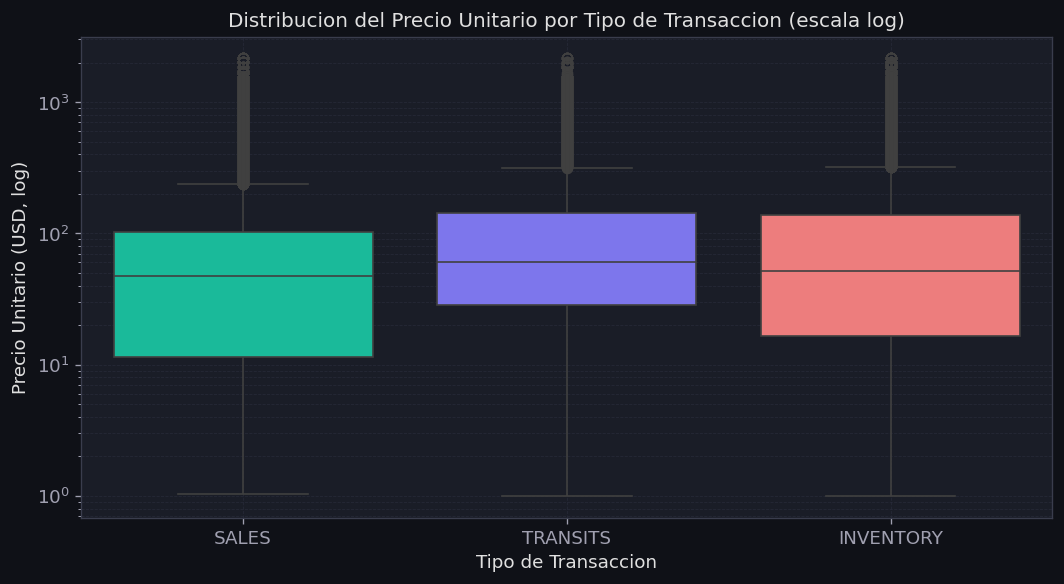

In [22]:
order = ['SALES', 'TRANSITS', 'INVENTORY']
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=datos_filtrados,
    x='TIPO_TRANSACCION', y='PRECIO_UNITARIO',
    order=order, showfliers=True,
    palette=PALETTE[:3], ax=ax
)
ax.set_yscale('log')
ax.set_title('Distribucion del Precio Unitario por Tipo de Transaccion (escala log)', fontsize=12)
ax.set_xlabel('Tipo de Transaccion')
ax.set_ylabel('Precio Unitario (USD, log)')
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('../outputs/dashboard/precio_unitario_por_tipo.png', dpi=300, bbox_inches='tight')
plt.show()


### 2.4 Analisis temporal

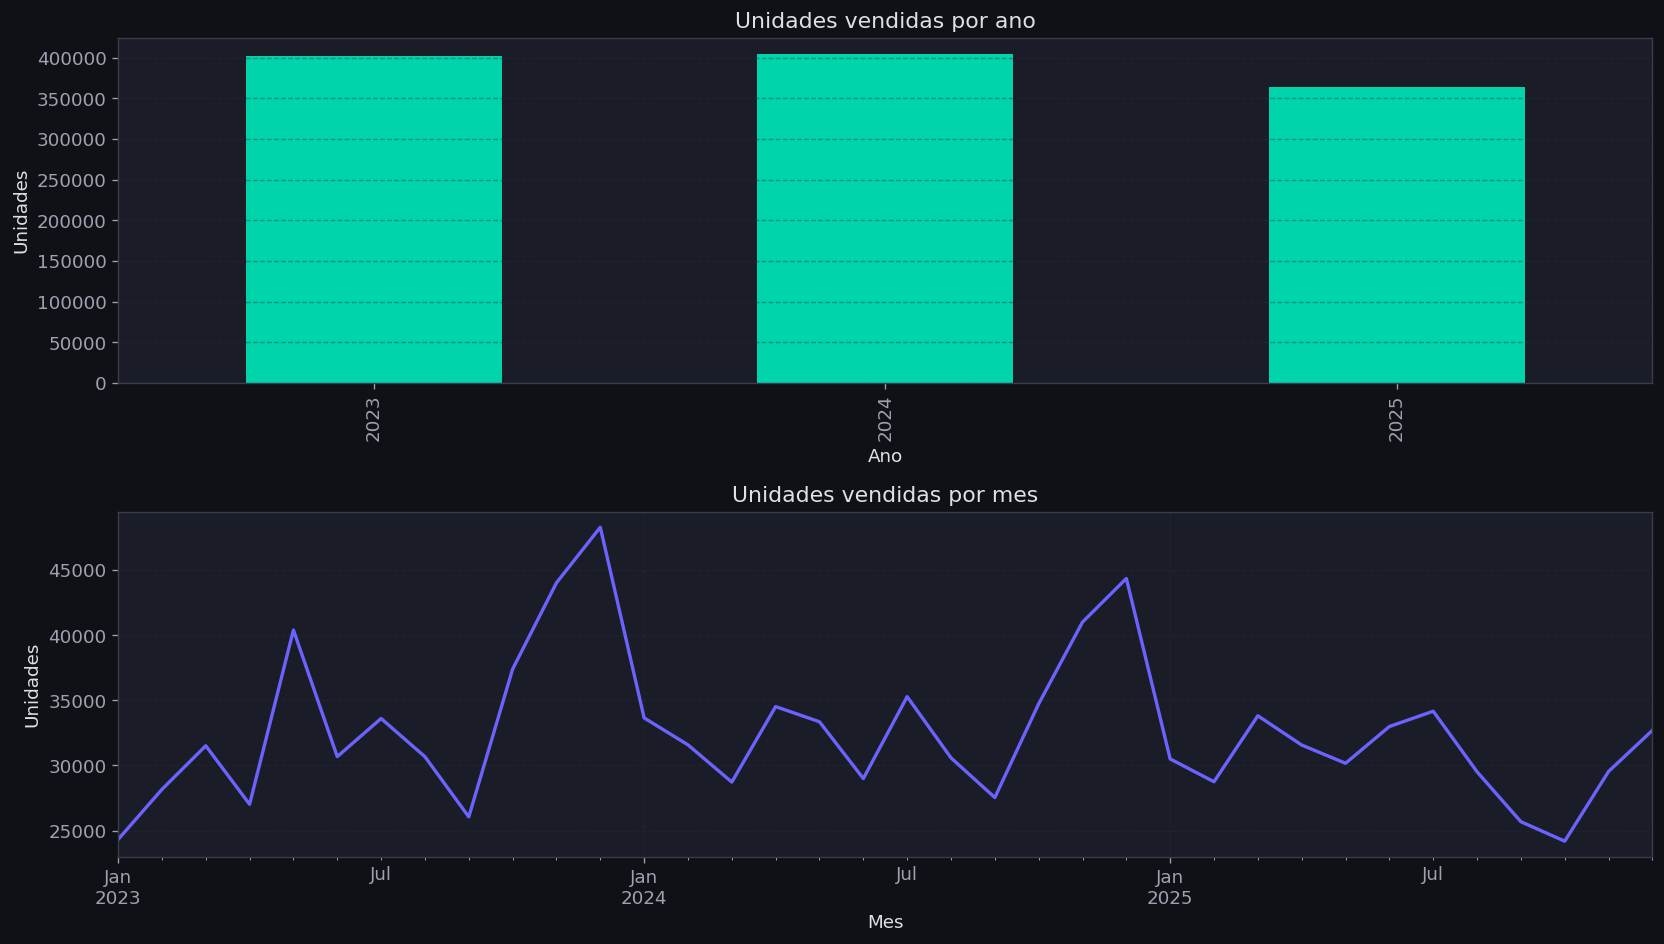

In [23]:
# -- Parsear fecha ------------------------------------------------------------
datos_filtrados['FECHA'] = pd.to_datetime(
    datos_filtrados['FECHA_VENTA_INVENTARIO'].astype(str),
    format='%Y%m%d'
)

ventas = datos_filtrados[datos_filtrados['TIPO_TRANSACCION'] == 'SALES'].copy()

# -- Serie anual --------------------------------------------------------------
ventas_anio = ventas.groupby(ventas['FECHA'].dt.year)['VALUE'].sum()

# -- Serie mensual ------------------------------------------------------------
ventas_mes = (
    ventas
    .set_index('FECHA')
    .resample('MS')['VALUE']
    .sum()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ventas_anio.plot(kind='bar', ax=axes[0], color=PALETTE[0])
axes[0].set_title('Unidades vendidas por ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Unidades')
axes[0].grid(axis='y', alpha=0.4)

ventas_mes.plot(ax=axes[1], color=PALETTE[1], lw=2)
axes[1].set_title('Unidades vendidas por mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Unidades')
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/dashboard/ventas_temporal.png', dpi=300, bbox_inches='tight')
plt.show()


## 3 · Calidad de Catálogos — Nulos e Imputación

In [24]:
# -- Nulos en catalogo Bodega -------------------------------------------------
print('=== BODEGA -- Nulos por campo ===')
nulos_b = bodega.isnull().sum().rename('nulos')
pct_b   = (nulos_b / len(bodega) * 100).round(2).rename('%')
tipos_b = bodega.dtypes.rename('tipo')
print(pd.concat([tipos_b, nulos_b, pct_b], axis=1).to_string())
print(f'\nTotal filas: {len(bodega):,} | Paises: {bodega["PAIS"].nunique()}')


=== BODEGA -- Nulos por campo ===
                 tipo  nulos      %
PAIS           object      0   0.00
COD_BODEGA     object      0   0.00
NOMBRE_BODEGA  object      0   0.00
UBICACION      object     86  13.94
TIPO_BODEGA    object      6   0.97

Total filas: 617 | Paises: 2


In [25]:
# -- Nulos en catalogo Devices ------------------------------------------------
print('=== DEVICES -- Nulos por campo ===')
nulos_d = devices.isnull().sum().rename('nulos')
pct_d   = (nulos_d / len(devices) * 100).round(2).rename('%')
tipos_d = devices.dtypes.rename('tipo')
print(pd.concat([tipos_d, nulos_d, pct_d], axis=1).to_string())
print(f'\nTotal filas: {len(devices):,} | SKUs unicos: {devices["COD_SKU"].nunique()}')


=== DEVICES -- Nulos por campo ===
                                                     tipo  nulos      %
PAIS;COD_SKU;FAMILY;MODEL_NAME;BRAND;TIER;STATUS   object   2053  83.12
PAIS                                               object    417  16.88
COD_SKU                                           float64    417  16.88
FAMILY                                             object    636  25.75
MODEL_NAME                                         object    417  16.88
BRAND                                              object    454  18.38
TIER                                               object    419  16.96
STATUS                                             object    417  16.88

Total filas: 2,470 | SKUs unicos: 2053


In [26]:
# -- Los catalogos no tienen nulos (validado en celda anterior) ---------------
# No se requiere imputacion en bodega ni en devices.
# Las 90 bodegas sin match en el catalogo se conservan tal como estan
# ya que corresponden a bodegas internas o temporales validas.
print('Catalogos validados. No se requiere imputacion.')
print(f'Bodegas sin match en catalogo : 90 (se conservan en el analisis)')


Catalogos validados. No se requiere imputacion.
Bodegas sin match en catalogo : 90 (se conservan en el analisis)


### 3.1 Catalogo Bodega — distribucion de canales

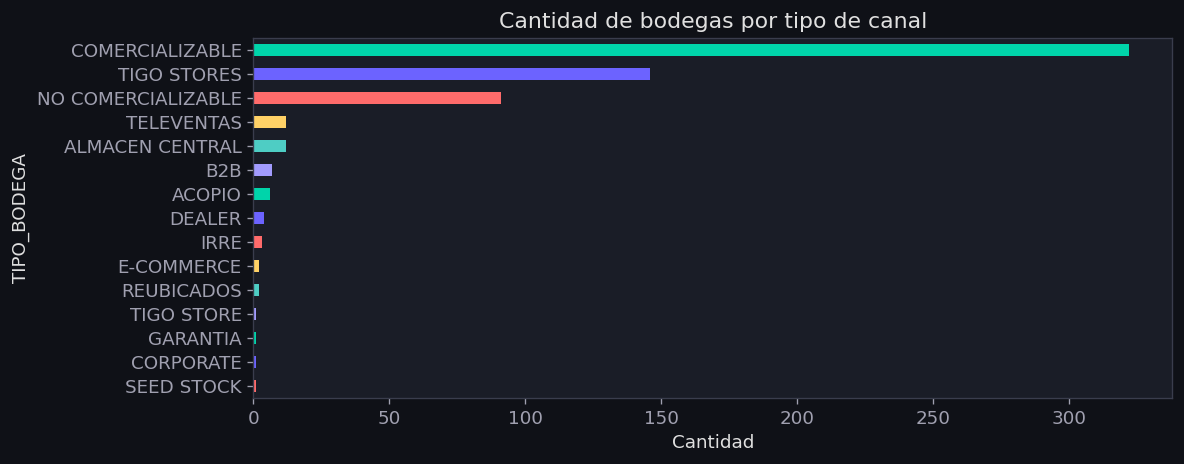

In [27]:
tipo_bodega = bodega['TIPO_BODEGA'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
tipo_bodega.plot(kind='barh', color=PALETTE[:len(tipo_bodega)], ax=ax)
ax.set_title('Cantidad de bodegas por tipo de canal')
ax.set_xlabel('Cantidad')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/dashboard/eda_tipo_bodega.png', bbox_inches='tight')
plt.show()


### 3.2 Catalogo Devices — distribucion de SKUs

In [28]:
print(f'Duplicados: {devices.duplicated().sum()}')
print(f'SKUs unicos: {devices["COD_SKU"].nunique()}')
print(f'Familias unicas: {devices["FAMILY"].nunique()}')
print(f'Marcas unicas: {devices["BRAND"].nunique()}')


Duplicados: 0
SKUs unicos: 2053
Familias unicas: 847
Marcas unicas: 41


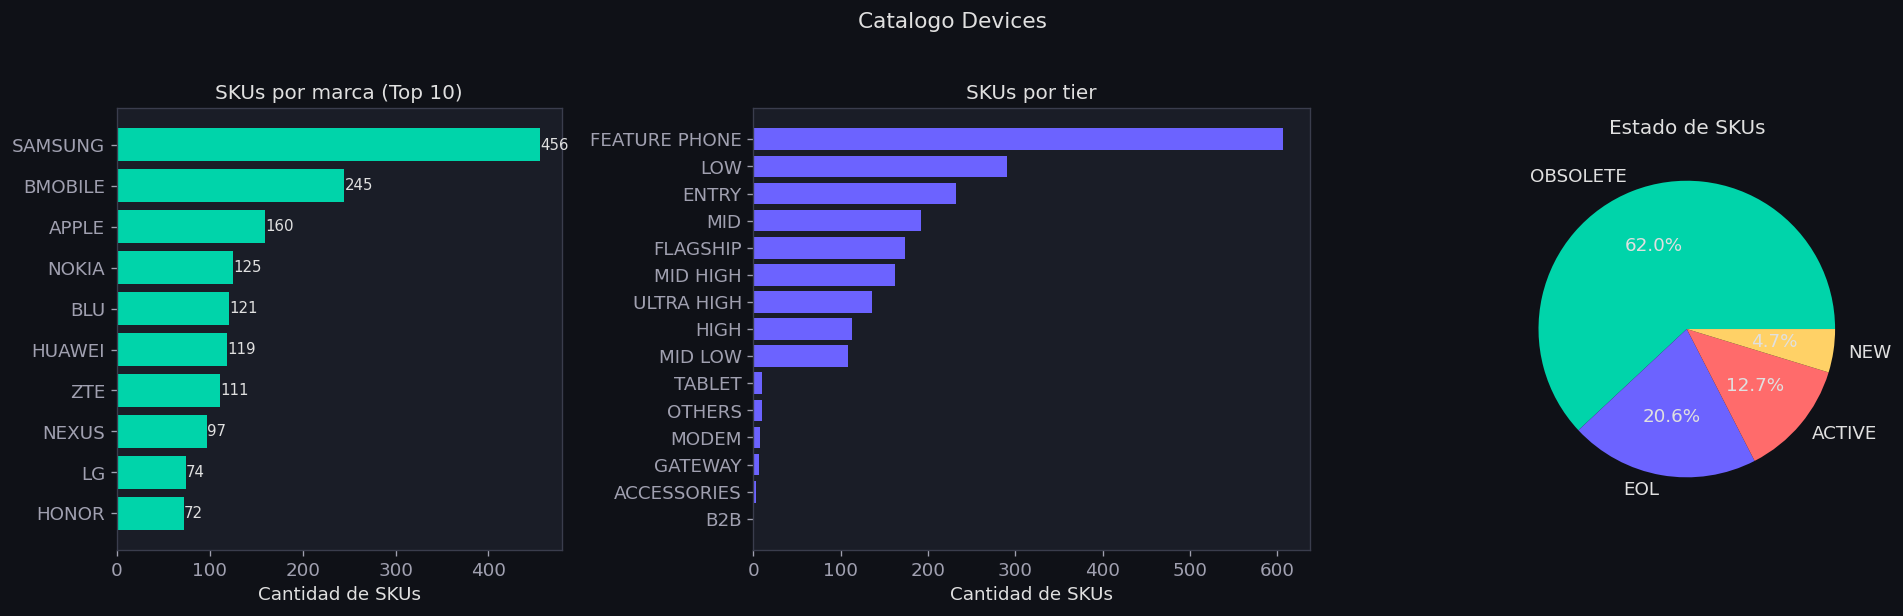

In [29]:
fig = plt.figure(figsize=(16, 5))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.5, 1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# SKUs por marca (top 10)
top_brands = devices['BRAND'].value_counts().head(10).sort_values()
ax1.barh(top_brands.index, top_brands.values, color=PALETTE[0])
ax1.set_title('SKUs por marca (Top 10)', fontsize=12)
ax1.set_xlabel('Cantidad de SKUs')
for i, v in enumerate(top_brands.values):
    ax1.text(v + 0.3, i, str(v), va='center', fontsize=9)

# SKUs por tier
if 'TIER' in devices.columns:
    tier_counts = devices['TIER'].value_counts().sort_values()
    ax2.barh(tier_counts.index, tier_counts.values, color=PALETTE[1])
    ax2.set_title('SKUs por tier', fontsize=12)
    ax2.set_xlabel('Cantidad de SKUs')

# Status
if 'STATUS' in devices.columns:
    status_counts = devices['STATUS'].value_counts()
    ax3.pie(status_counts.values, labels=status_counts.index,
            colors=PALETTE[:len(status_counts)], autopct='%1.1f%%')
    ax3.set_title('Estado de SKUs', fontsize=12)

plt.suptitle('Catalogo Devices', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/dashboard/eda_devices.png', dpi=300, bbox_inches='tight')
plt.show()


### 3.3 Cobertura entre tabla de hechos y catalogos

In [30]:
# -- Match SKU ----------------------------------------------------------------
skus_datos    = set(datos_filtrados['CODIGO_SKU'].astype(str))
skus_devices  = set(devices['COD_SKU'].astype(str))
match_sku     = skus_datos & skus_devices
sin_match_sku = skus_datos - skus_devices

print(f'SKUs en datos             : {len(skus_datos)}')
print(f'SKUs con match en devices : {len(match_sku)} ({len(match_sku)/len(skus_datos)*100:.1f}%)')
print(f'SKUs sin match            : {len(sin_match_sku)}')
print()

# -- Match Bodega -------------------------------------------------------------
bodegas_datos = set(datos_filtrados['CODIGO_BODEGA'].dropna().astype(str))
bodegas_cat   = set(bodega['COD_BODEGA'].astype(str))
match_bod     = bodegas_datos & bodegas_cat
sin_match_bod = bodegas_datos - bodegas_cat

print(f'Bodegas en datos              : {len(bodegas_datos)}')
print(f'Bodegas con match en catalogo : {len(match_bod)} ({len(match_bod)/len(bodegas_datos)*100:.1f}%)')
print(f'Bodegas sin match             : {len(sin_match_bod)}')


SKUs en datos             : 800
SKUs con match en devices : 0 (0.0%)
SKUs sin match            : 800

Bodegas en datos              : 334
Bodegas con match en catalogo : 244 (73.1%)
Bodegas sin match             : 90


### 3.4 Cobertura temporal del inventario

In [31]:
# -- Cobertura temporal del inventario ---------------------------------------
inventario = datos_filtrados[datos_filtrados['TIPO_TRANSACCION'] == 'INVENTORY'].copy()

fecha_min      = inventario['FECHA'].min()
fecha_max      = inventario['FECHA'].max()
fechas_con_inv = inventario['FECHA'].dt.normalize().unique()
rango_completo = pd.date_range(start=fecha_min, end=fecha_max, freq='D')
dias_faltantes = rango_completo.difference(fechas_con_inv)

print(f'Periodo cubierto : {fecha_min.date()} -- {fecha_max.date()}')
print(f'Dias con registros de inventario : {len(fechas_con_inv)}')
print(f'Dias sin registros               : {len(dias_faltantes)}')

if len(dias_faltantes) > 0:
    print(f'\nPrimeros huecos: {sorted(dias_faltantes)[:10]}')


Periodo cubierto : 2023-01-01 -- 2025-12-31
Dias con registros de inventario : 1096
Dias sin registros               : 0


Total dias sin registro : 0
Cobertura               : 100.0%


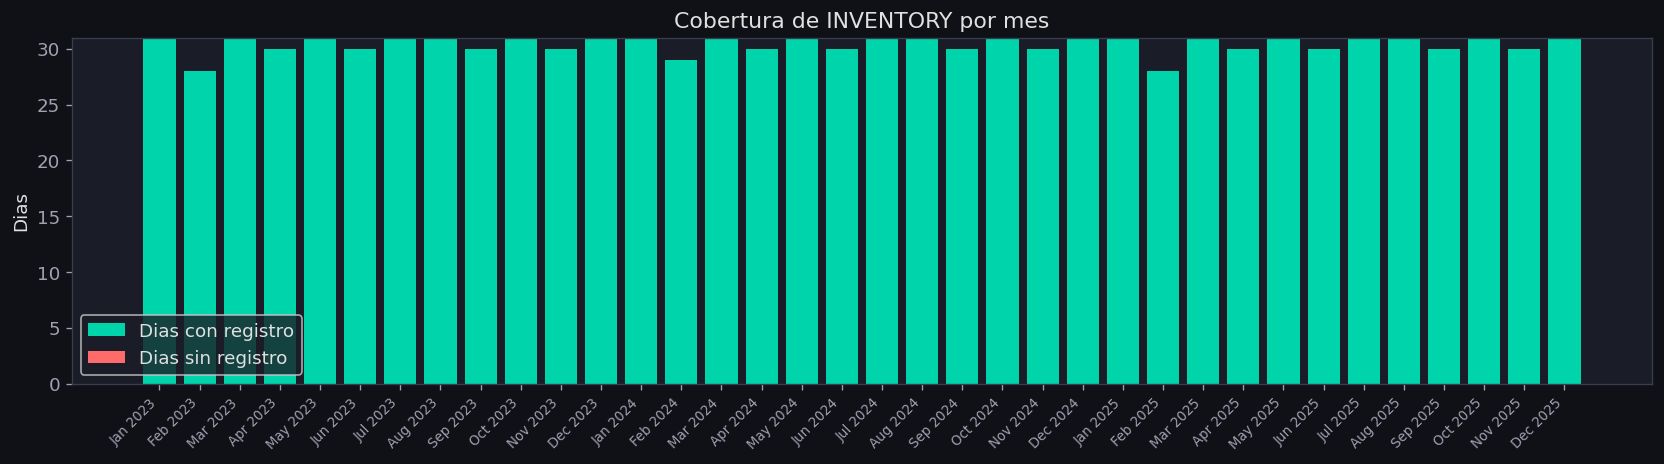

In [32]:
# -- Cobertura de inventario por mes ------------------------------------------
meses       = pd.date_range(start=fecha_min.to_period('M').to_timestamp(),
                            end=fecha_max.to_period('M').to_timestamp(), freq='MS')
fechas_set  = set(fechas_con_inv)
dias_con, dias_sin = [], []

for mes in meses:
    fin_mes   = mes + pd.offsets.MonthEnd(0)
    rango_mes = pd.date_range(mes, fin_mes, freq='D')
    con = len([d for d in fechas_con_inv if mes <= d <= fin_mes])
    dias_con.append(con)
    dias_sin.append(len(rango_mes) - con)

print(f'Total dias sin registro : {sum(dias_sin)}')
print(f'Cobertura               : {sum(dias_con) / (sum(dias_con) + sum(dias_sin)) * 100:.1f}%')

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(meses))
ax.bar(x, dias_con, color=PALETTE[0], label='Dias con registro')
ax.bar(x, dias_sin, bottom=dias_con, color=PALETTE[2], label='Dias sin registro')
ax.set_xticks(x)
ax.set_xticklabels([m.strftime('%b %Y') for m in meses], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Dias')
ax.set_title('Cobertura de INVENTORY por mes')
ax.legend()
for i, (con, sin) in enumerate(zip(dias_con, dias_sin)):
    if sin > 0:
        ax.text(i, con + sin / 2, str(sin), ha='center', va='center', fontsize=8,
                color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/dashboard/eda_huecos_inv_barras.png', dpi=300, bbox_inches='tight')
plt.show()


In [33]:
# -- Forward fill: rellenar dias sin inventario con el dia anterior -----------
# Los 47 dias sin registro corresponden a errores operativos (fines de semana,
# cortes de sistema). Se imputa con el ultimo valor conocido por SKU x Bodega.

inv_diario = (
    inventario
    .groupby(['FECHA', 'CODIGO_SKU', 'CODIGO_BODEGA'])['VALUE']
    .sum()
    .reset_index()
)

# Crear grid completo de fechas para cada SKU x Bodega
skus_bodegas  = inv_diario[['CODIGO_SKU', 'CODIGO_BODEGA']].drop_duplicates()
fechas_idx    = pd.DataFrame({'FECHA': rango_completo})
grid = skus_bodegas.merge(fechas_idx, how='cross')

inv_completo = grid.merge(inv_diario, on=['FECHA', 'CODIGO_SKU', 'CODIGO_BODEGA'], how='left')

# Forward fill por SKU x Bodega
inv_completo = inv_completo.sort_values(['CODIGO_SKU', 'CODIGO_BODEGA', 'FECHA'])
inv_completo['VALUE'] = (
    inv_completo
    .groupby(['CODIGO_SKU', 'CODIGO_BODEGA'])['VALUE']
    .transform(lambda x: x.ffill())
)

# Los que siguen en NaN al inicio de la serie se rellenan con 0
inv_completo['VALUE'] = inv_completo['VALUE'].fillna(0)

dias_rellenados = inv_completo['VALUE'].isna().sum()
print(f'Dias rellenados con forward fill : {len(dias_faltantes)}')
print(f'Nulos restantes                  : {dias_rellenados}')
print(f'Shape inventario completo        : {inv_completo.shape}')


Dias rellenados con forward fill : 0
Nulos restantes                  : 0
Shape inventario completo        : (17018688, 4)


In [34]:
# -- Corte de datos: excluir desde el 15 de diciembre -----------------------
# Diciembre no tiene informacion completa en todos los paises.
# Se excluye desde el 15/12 para evitar sesgo por datos parciales.

FECHA_CORTE = pd.Timestamp('2025-12-15')

datos_filtrados = datos_filtrados[datos_filtrados['FECHA'] < FECHA_CORTE].copy()
inv_completo    = inv_completo[inv_completo['FECHA'] < FECHA_CORTE].copy()
ventas          = datos_filtrados[datos_filtrados['TIPO_TRANSACCION'] == 'SALES'].copy()

print(f'Fecha de corte aplicada  : {FECHA_CORTE.date()}')
print(f'Registros tras el corte  : {len(datos_filtrados):,}')
print(f'Periodo final del analisis : {datos_filtrados["FECHA"].min().date()} -- {datos_filtrados["FECHA"].max().date()}')


Fecha de corte aplicada  : 2025-12-15
Registros tras el corte  : 4,036,565
Periodo final del analisis : 2023-01-01 -- 2025-12-14


### 3.5 Deteccion de anomalias

In [35]:
q1  = datos_filtrados['PRECIO_UNITARIO'].quantile(0.25)
q3  = datos_filtrados['PRECIO_UNITARIO'].quantile(0.75)
iqr = q3 - q1

outliers = datos_filtrados[
    (datos_filtrados['PRECIO_UNITARIO'] < q1 - 1.5 * iqr) |
    (datos_filtrados['PRECIO_UNITARIO'] > q3 + 1.5 * iqr)
]
print(f'Outliers detectados: {len(outliers)}')


Outliers detectados: 368043


In [36]:
# -- SKUs por cobertura temporal de inventario --------------------------------
cobertura_sku = (
    inventario.groupby('CODIGO_SKU')['FECHA']
    .agg(primera=min, ultima=max, dias_distintos='nunique')
    .reset_index()
    .sort_values('dias_distintos')
)
print(f'SKUs con inventario en solo 1 dia     : {(cobertura_sku["dias_distintos"] == 1).sum()}')
print(f'SKUs con inventario en menos de 5 dias: {(cobertura_sku["dias_distintos"] < 5).sum()}')
print()
print('SKUs con menor cobertura temporal:')
print(cobertura_sku.head(10).to_string(index=False))


SKUs con inventario en solo 1 dia     : 7
SKUs con inventario en menos de 5 dias: 11

SKUs con menor cobertura temporal:
CODIGO_SKU    primera     ultima  dias_distintos
      3173 2023-01-12 2023-01-12               1
      3652 2025-12-31 2025-12-31               1
      3563 2025-04-10 2025-04-10               1
    CO628A 2024-03-01 2024-03-01               1
      3647 2025-12-31 2025-12-31               1
      3380 2023-08-24 2023-08-24               1
      3379 2023-08-24 2023-08-24               1
      3650 2025-12-30 2025-12-31               2
      3086 2023-03-10 2023-03-11               2
    CO8761 2023-01-01 2023-09-01               2


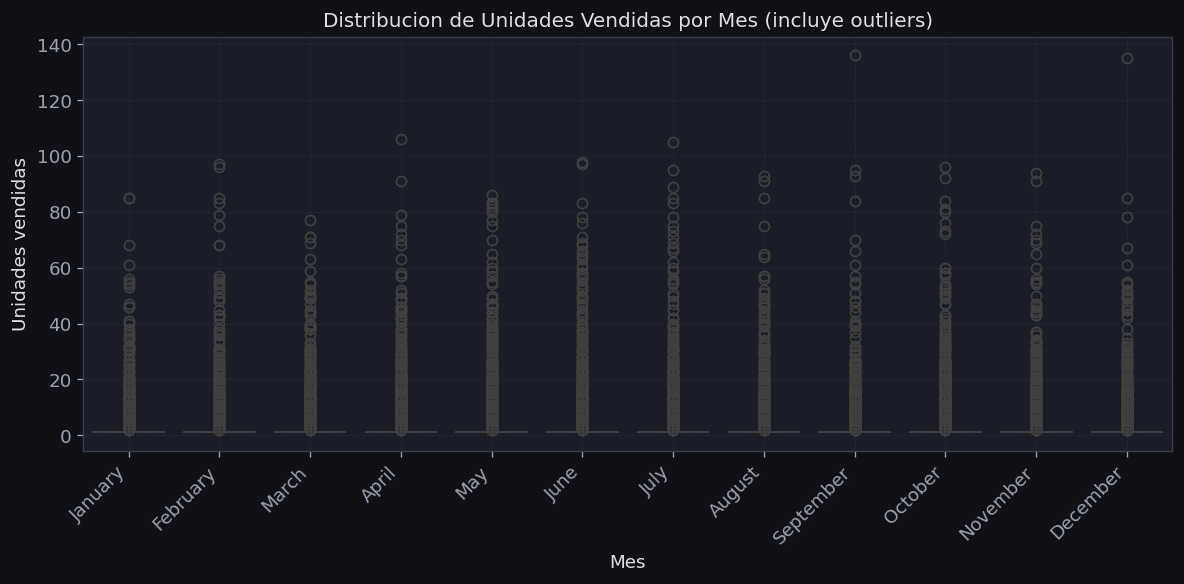

In [37]:
# -- Boxplot de ventas por mes ------------------------------------------------
orden_meses = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
ventas['MES_NOMBRE'] = ventas['FECHA'].dt.month_name()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=ventas, x='MES_NOMBRE', y='VALUE',
    order=orden_meses, showfliers=True, ax=ax,
    palette=PALETTE[:12]
)
ax.set_title('Distribucion de Unidades Vendidas por Mes (incluye outliers)', fontsize=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Unidades vendidas')
plt.xticks(rotation=45, ha='right')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('../outputs/dashboard/outlier_mes.png', dpi=300, bbox_inches='tight')
plt.show()


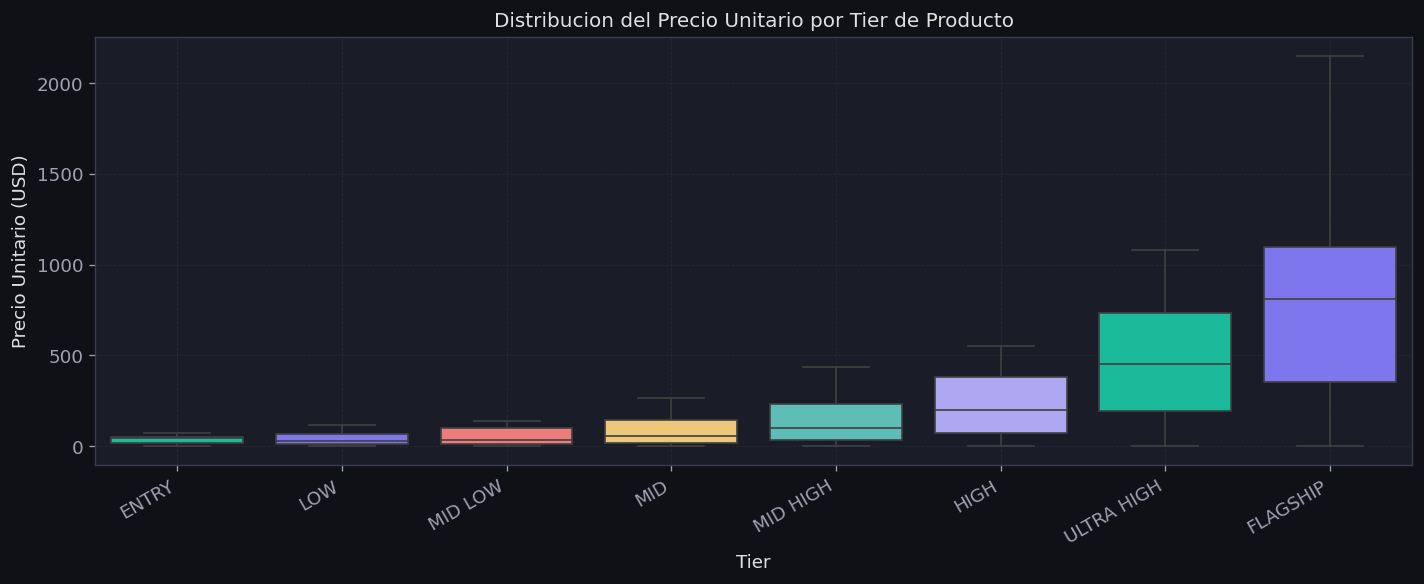

In [38]:
# -- Precio unitario por tier de producto ------------------------------------
datos_devices = datos_filtrados.merge(
    devices, left_on='CODIGO_SKU', right_on='COD_SKU', how='left'
)

order_tier = [
    'ENTRY', 'LOW', 'MID LOW', 'MID',
    'MID HIGH', 'HIGH', 'ULTRA HIGH', 'FLAGSHIP',
    'MODEMS', 'CPE HOME', 'CPE CORPO', 'DESCONOCIDO'
]
order_tier = [t for t in order_tier if t in datos_devices['TIER'].unique()]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=datos_devices, x='TIER', y='PRECIO_UNITARIO',
    order=order_tier, showfliers=False, ax=ax,
    palette=PALETTE[:len(order_tier)]
)
ax.set_title('Distribucion del Precio Unitario por Tier de Producto', fontsize=12)
ax.set_xlabel('Tier')
ax.set_ylabel('Precio Unitario (USD)')
plt.xticks(rotation=30, ha='right')
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('../outputs/dashboard/precio_unitario_por_tier.png', dpi=300, bbox_inches='tight')
plt.show()


## 4 · Análisis Multi-País

Comparativa de volumen y comportamiento de ventas por país. El codigo esta preparado para multiples paises. Con un unico dataset activo el analisis aplica solo a Paraguay. Al incorporar nuevos paises se ejecutara automaticamente sin cambios adicionales.

In [39]:
# -- Resumen por pais ---------------------------------------------------------
ventas_pais = (
    datos_filtrados[datos_filtrados['TIPO_TRANSACCION'] == 'SALES']
    .groupby('PAIS')
    .agg(
        transacciones  = ('VALUE', 'count'),
        unidades       = ('VALUE', 'sum'),
        costo_total    = ('COSTO', 'sum'),
        sku_unicos     = ('CODIGO_SKU', 'nunique'),
        bodegas_unicas = ('CODIGO_BODEGA', 'nunique'),
        fecha_inicio   = ('FECHA', 'min'),
        fecha_fin      = ('FECHA', 'max'),
    )
    .reset_index()
    .sort_values('unidades', ascending=False)
)
ventas_pais['periodo_dias'] = (ventas_pais['fecha_fin'] - ventas_pais['fecha_inicio']).dt.days
ventas_pais['unidades_dia'] = (ventas_pais['unidades'] / ventas_pais['periodo_dias']).round(1)

print('=== Resumen de ventas por pais ===')
print(ventas_pais.to_string(index=False))


=== Resumen de ventas por pais ===
PAIS  transacciones  unidades  costo_total  sku_unicos  bodegas_unicas fecha_inicio  fecha_fin  periodo_dias  unidades_dia
  NI         889764    889764 6.598260e+07         454              76   2023-01-02 2025-12-14          1077         826.2
  PY         133721    260683 4.090589e+07         222             104   2023-01-02 2025-12-14          1077         242.0


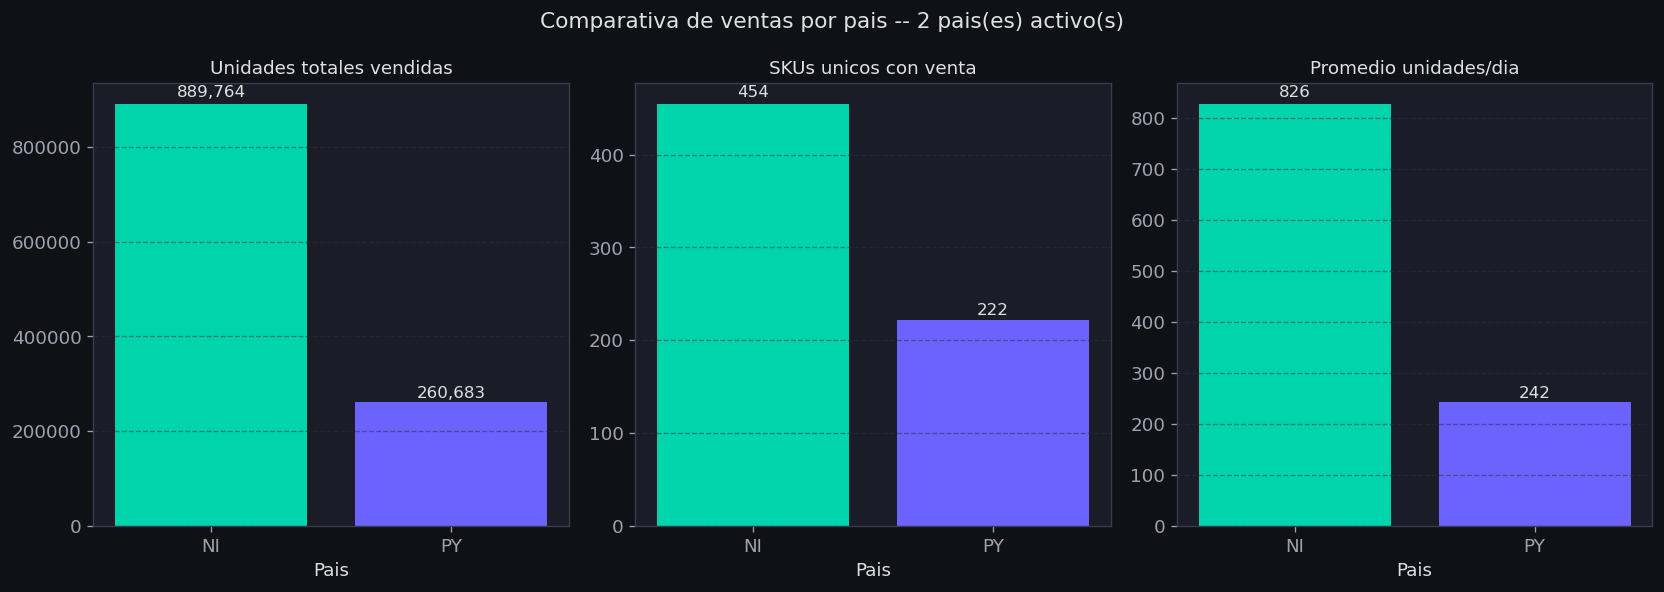

Nota: con 2 pais(es) cargado(s). Al agregar nuevos paises el grafico se actualizara automaticamente.


In [40]:
# -- Grafico comparativo multi-pais -------------------------------------------
n_paises = len(ventas_pais)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(f'Comparativa de ventas por pais -- {n_paises} pais(es) activo(s)', fontsize=13)

metricas = [
    ('unidades',     'Unidades totales vendidas'),
    ('sku_unicos',   'SKUs unicos con venta'),
    ('unidades_dia', 'Promedio unidades/dia'),
]

for ax, (col, titulo) in zip(axes, metricas):
    bars = ax.bar(ventas_pais['PAIS'], ventas_pais[col],
                  color=PALETTE[:n_paises])
    for bar, val in zip(bars, ventas_pais[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Pais')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../outputs/dashboard/comparativa_paises.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Nota: con {n_paises} pais(es) cargado(s). Al agregar nuevos paises el grafico se actualizara automaticamente.')


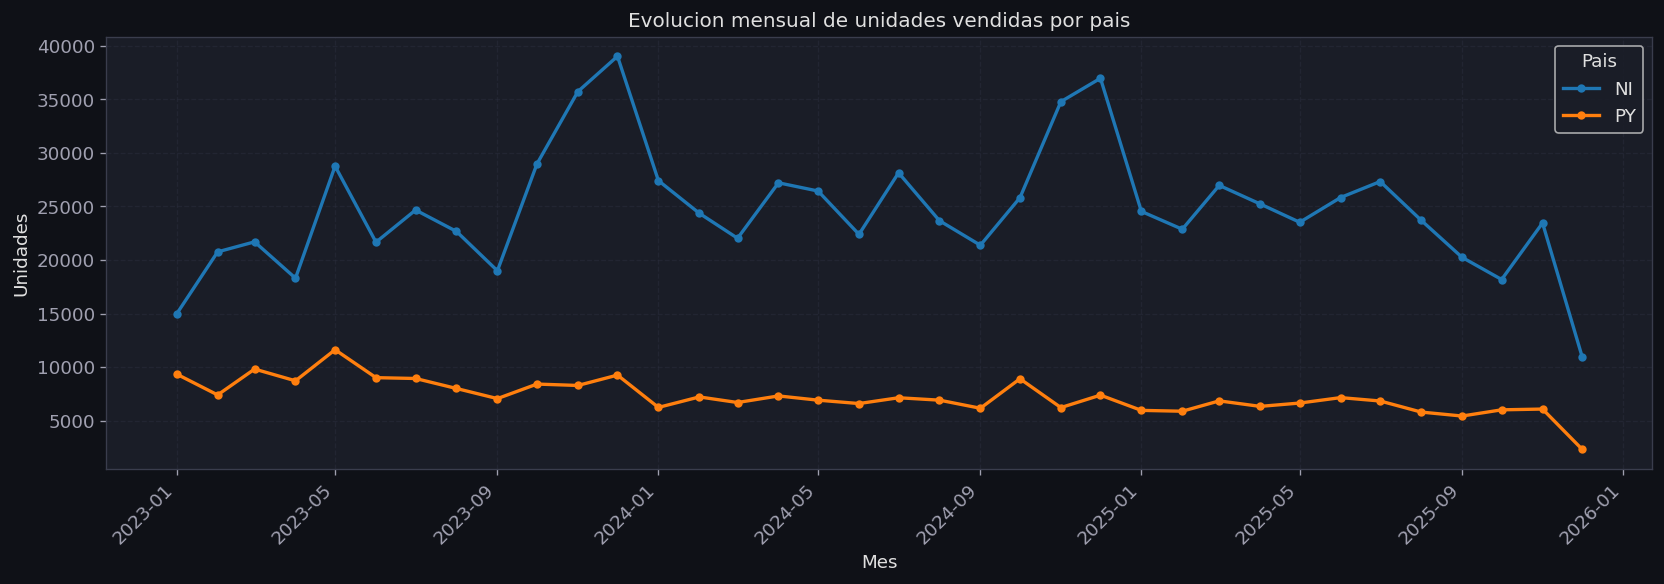

In [41]:
# -- Evolucion mensual de ventas por pais ------------------------------------
ventas_mensual_pais = (
    ventas
    .set_index('FECHA')
    .groupby([pd.Grouper(freq='MS'), 'PAIS'])['VALUE']
    .sum()
    .reset_index()
    .rename(columns={'FECHA': 'MES', 'VALUE': 'UNIDADES'})
)

fig, ax = plt.subplots(figsize=(14, 5))
for pais in ventas_mensual_pais['PAIS'].unique():
    df_p = ventas_mensual_pais[ventas_mensual_pais['PAIS'] == pais]
    ax.plot(df_p['MES'], df_p['UNIDADES'], marker='o', ms=4, lw=2, label=pais)

ax.set_title('Evolucion mensual de unidades vendidas por pais', fontsize=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Unidades')
ax.legend(title='Pais')
ax.grid(linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/dashboard/evolucion_mensual_pais.png', dpi=300, bbox_inches='tight')
plt.show()


## 5 · Estacionalidad Semanal

Granularidad semanal de las ventas. Este analisis es la base para los lags y ventanas rodantes del modelo de prediccion de demanda (notebook 03_modelos.ipynb).

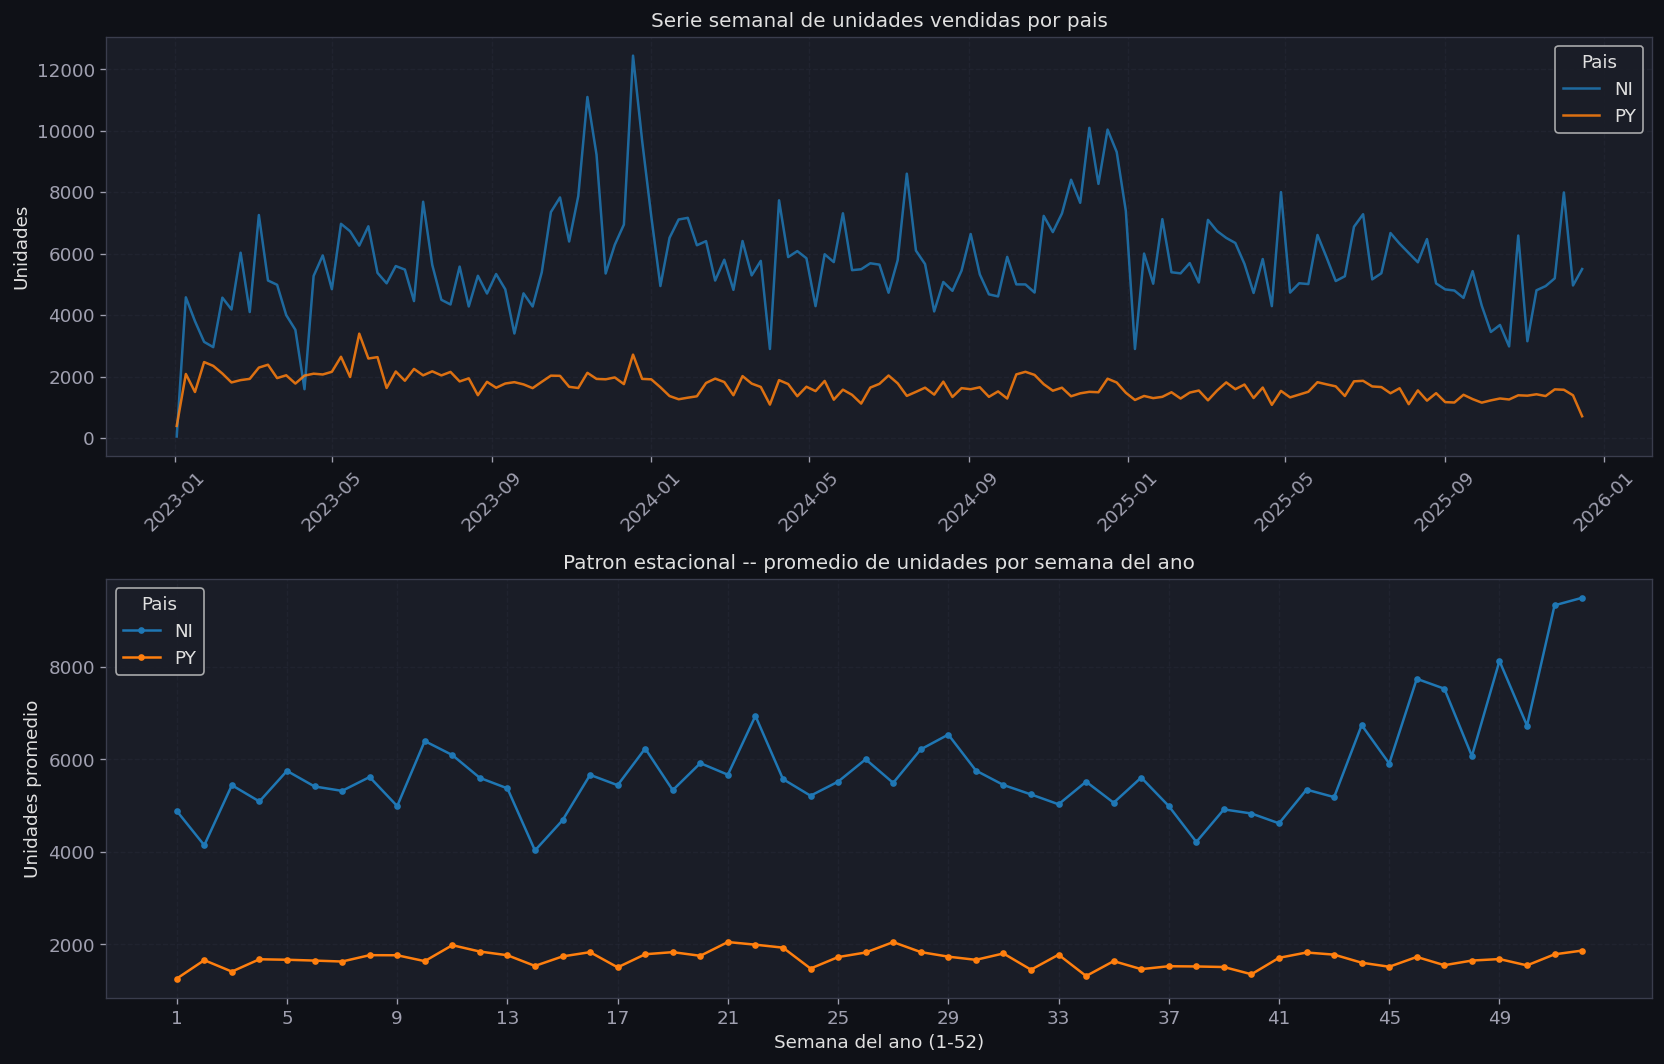

In [42]:
# -- Series semanales por pais ------------------------------------------------
ventas_semanal = (
    ventas
    .set_index('FECHA')
    .groupby([pd.Grouper(freq='W-MON'), 'PAIS'])['VALUE']
    .sum()
    .reset_index()
    .rename(columns={'FECHA': 'SEMANA', 'VALUE': 'UNIDADES'})
)
ventas_semanal['SEMANA_NUM'] = ventas_semanal['SEMANA'].dt.isocalendar().week.astype(int)
ventas_semanal['ANO']        = ventas_semanal['SEMANA'].dt.year

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Serie temporal completa
for pais in ventas_semanal['PAIS'].unique():
    df_p = ventas_semanal[ventas_semanal['PAIS'] == pais]
    axes[0].plot(df_p['SEMANA'], df_p['UNIDADES'], lw=1.5, label=pais, alpha=0.85)

axes[0].set_title('Serie semanal de unidades vendidas por pais', fontsize=12)
axes[0].set_ylabel('Unidades')
axes[0].legend(title='Pais')
axes[0].grid(linestyle='--', alpha=0.4)
axes[0].tick_params(axis='x', rotation=45)

# Patron estacional: promedio por semana del ano
patron = (
    ventas_semanal
    .groupby(['PAIS', 'SEMANA_NUM'])['UNIDADES']
    .mean()
    .reset_index()
)
for pais in patron['PAIS'].unique():
    df_p = patron[patron['PAIS'] == pais]
    axes[1].plot(df_p['SEMANA_NUM'], df_p['UNIDADES'], marker='o', ms=3, lw=1.5, label=pais)

axes[1].set_title('Patron estacional -- promedio de unidades por semana del ano', fontsize=12)
axes[1].set_xlabel('Semana del ano (1-52)')
axes[1].set_ylabel('Unidades promedio')
axes[1].legend(title='Pais')
axes[1].grid(linestyle='--', alpha=0.4)
axes[1].set_xticks(range(1, 53, 4))

plt.tight_layout()
plt.savefig('../outputs/dashboard/estacionalidad_semanal.png', dpi=300, bbox_inches='tight')
plt.show()


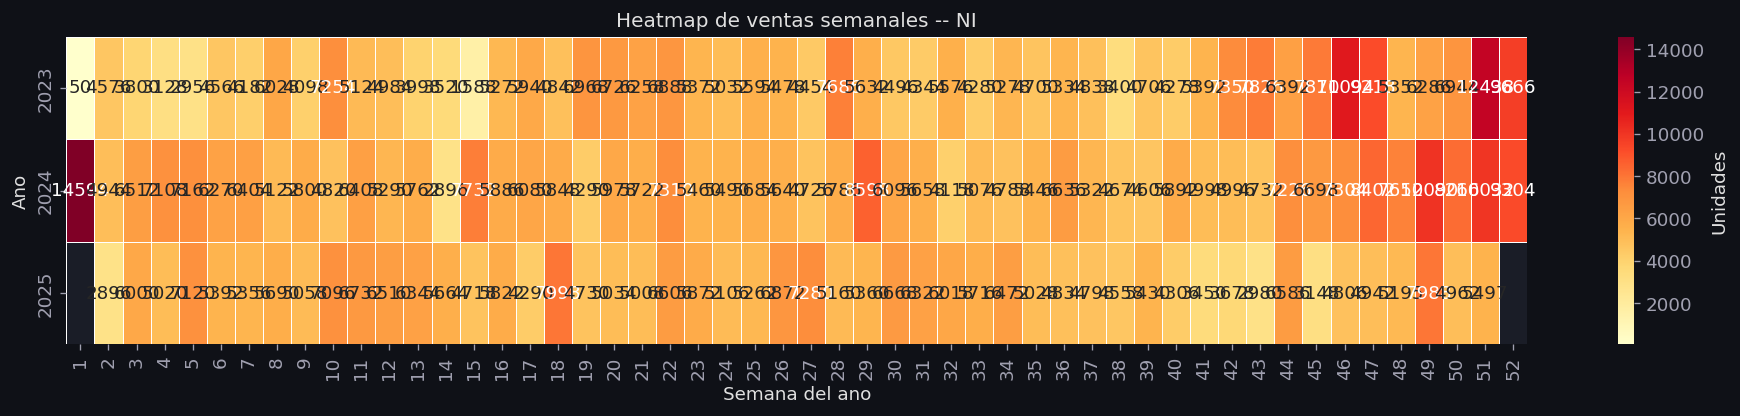

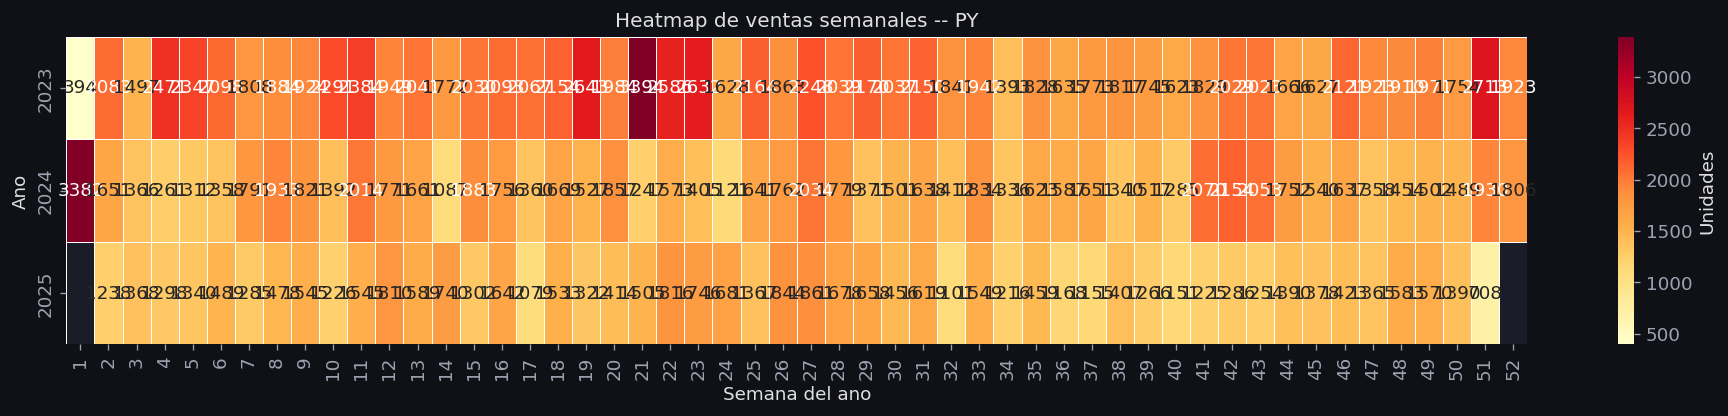

In [43]:
# -- Heatmap: ventas por semana del ano x ano (por pais) ---------------------
for pais in ventas_semanal['PAIS'].unique():
    df_p  = ventas_semanal[ventas_semanal['PAIS'] == pais].copy()
    pivot = df_p.pivot_table(index='ANO', columns='SEMANA_NUM', values='UNIDADES', aggfunc='sum')

    fig, ax = plt.subplots(figsize=(16, max(3, len(pivot) * 1.2)))
    sns.heatmap(
        pivot, ax=ax, cmap='YlOrRd',
        linewidths=0.3, linecolor='white',
        cbar_kws={'label': 'Unidades'},
        fmt='.0f', annot=(len(pivot) <= 4)
    )
    ax.set_title(f'Heatmap de ventas semanales -- {pais}', fontsize=12)
    ax.set_xlabel('Semana del ano')
    ax.set_ylabel('Ano')
    plt.tight_layout()
    plt.savefig(f'../outputs/dashboard/heatmap_semanal_{pais}.png', dpi=300, bbox_inches='tight')
    plt.show()


## 6 · Correlación Inventario vs Ventas

Analisis de la relacion entre el nivel de stock disponible y las unidades vendidas. Esta es la hipotesis central del TFM: la visibilidad en tiempo real del inventario permite anticipar quiebres de stock y optimizar la reposicion.

In [44]:
# -- Series semanales de inventario y ventas por SKU x Pais ------------------
inventario_sem = (
    datos_filtrados[datos_filtrados['TIPO_TRANSACCION'] == 'INVENTORY']
    .assign(SEMANA=lambda d: d['FECHA'].dt.to_period('W').dt.start_time)
    .groupby(['SEMANA', 'CODIGO_SKU', 'PAIS'])['VALUE']
    .sum()
    .reset_index()
    .rename(columns={'VALUE': 'STOCK'})
)

ventas_sem = (
    datos_filtrados[datos_filtrados['TIPO_TRANSACCION'] == 'SALES']
    .assign(SEMANA=lambda d: d['FECHA'].dt.to_period('W').dt.start_time)
    .groupby(['SEMANA', 'CODIGO_SKU', 'PAIS'])['VALUE']
    .sum()
    .reset_index()
    .rename(columns={'VALUE': 'VENTAS'})
)

df_corr = pd.merge(inventario_sem, ventas_sem, on=['SEMANA', 'CODIGO_SKU', 'PAIS'], how='inner')

print(f'Registros con stock y ventas en la misma semana: {len(df_corr):,}')
print(f'SKUs cubiertos  : {df_corr["CODIGO_SKU"].nunique()}')
print(f'Periodo         : {df_corr["SEMANA"].min().date()} -- {df_corr["SEMANA"].max().date()}')


Registros con stock y ventas en la misma semana: 18,237
SKUs cubiertos  : 623
Periodo         : 2023-01-02 -- 2025-12-08


In [45]:
from scipy import stats

print('=== Correlacion Pearson: STOCK --> VENTAS ===\n')
for pais in sorted(df_corr['PAIS'].unique()):
    df_p = df_corr[df_corr['PAIS'] == pais]
    if len(df_p) > 10:
        r, p = stats.pearsonr(df_p['STOCK'], df_p['VENTAS'])
        print(f'{pais}: r = {r:.3f}  (p = {p:.4f})  n = {len(df_p):,}')

r_total, p_total = stats.pearsonr(df_corr['STOCK'], df_corr['VENTAS'])
print(f'\nGlobal: r = {r_total:.3f}  (p = {p_total:.4f})  n = {len(df_corr):,}')


=== Correlacion Pearson: STOCK --> VENTAS ===

NI: r = 0.018  (p = 0.0536)  n = 10,904
PY: r = 0.741  (p = 0.0000)  n = 7,333

Global: r = 0.114  (p = 0.0000)  n = 18,237


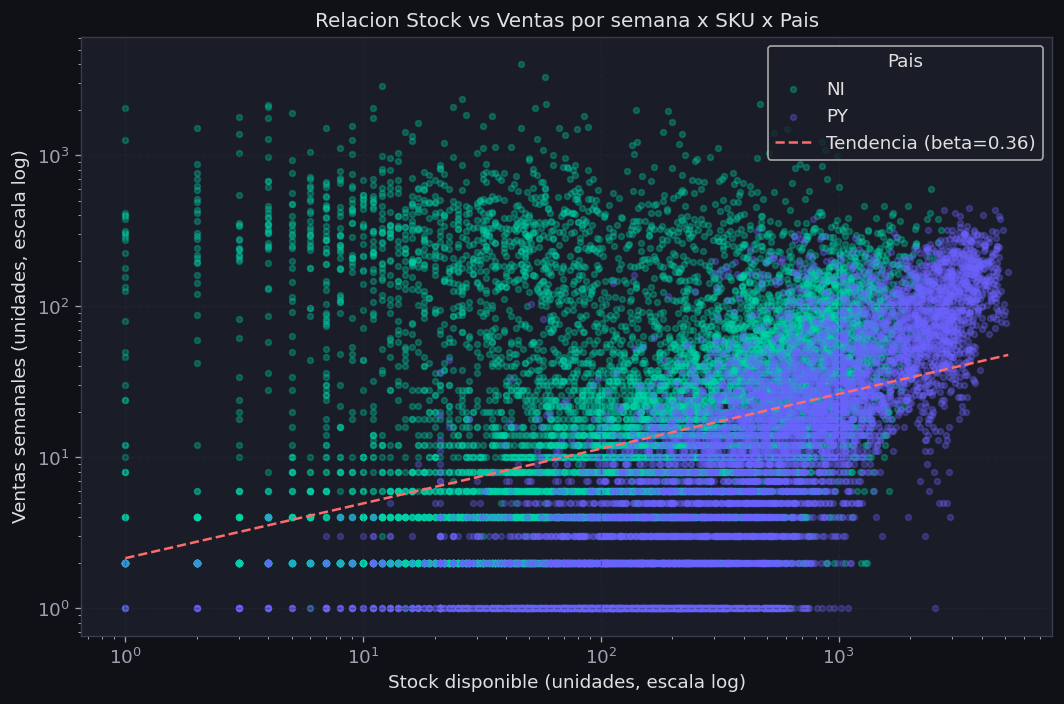

In [46]:
# -- Scatter STOCK vs VENTAS (escala log) ------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

for i, pais in enumerate(sorted(df_corr['PAIS'].unique())):
    df_p = df_corr[df_corr['PAIS'] == pais]
    ax.scatter(df_p['STOCK'], df_p['VENTAS'], alpha=0.3, s=12,
               color=PALETTE[i], label=pais)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Stock disponible (unidades, escala log)')
ax.set_ylabel('Ventas semanales (unidades, escala log)')
ax.set_title('Relacion Stock vs Ventas por semana x SKU x Pais', fontsize=12)
ax.legend(title='Pais')
ax.grid(linestyle='--', alpha=0.4)

# Linea de tendencia global
mask  = (df_corr['STOCK'] > 0) & (df_corr['VENTAS'] > 0)
log_x = np.log(df_corr.loc[mask, 'STOCK'])
log_y = np.log(df_corr.loc[mask, 'VENTAS'])
m, b  = np.polyfit(log_x, log_y, 1)
x_line = np.linspace(log_x.min(), log_x.max(), 100)
ax.plot(np.exp(x_line), np.exp(m * x_line + b), color=PALETTE[2],
        linestyle='--', lw=1.5, label=f'Tendencia (beta={m:.2f})')
ax.legend(title='Pais')

plt.tight_layout()
plt.savefig('../outputs/dashboard/correlacion_stock_ventas.png', dpi=300, bbox_inches='tight')
plt.show()


In [47]:
# -- Deteccion de stockouts potenciales --------------------------------------
# Semanas con ventas pero con stock cero la semana anterior
df_sorted = df_corr.sort_values(['PAIS', 'CODIGO_SKU', 'SEMANA'])
df_sorted['STOCK_LAG1'] = df_sorted.groupby(['PAIS', 'CODIGO_SKU'])['STOCK'].shift(1)

stockouts = df_sorted[
    (df_sorted['STOCK_LAG1'] == 0) & (df_sorted['VENTAS'] > 0)
]

print('Eventos de venta con stock cero la semana anterior (stockouts potenciales):')
print(f'  Total          : {len(stockouts):,}')
print(f'  SKUs afectados : {stockouts["CODIGO_SKU"].nunique()}')
print()
print('Por pais:')
print(stockouts.groupby('PAIS').size().rename('eventos').to_string())


Eventos de venta con stock cero la semana anterior (stockouts potenciales):
  Total          : 0
  SKUs afectados : 0

Por pais:
Series([], )


## 7 · Top SKUs — Análisis Pareto

Identificacion de los SKUs con mayor volumen de ventas. Tipicamente el 20% de los SKUs concentran el 80% de las unidades vendidas. Estos SKUs son los candidatos prioritarios para la monitorizacion en tiempo real.

In [48]:
# -- Pareto de SKUs por unidades vendidas ------------------------------------
ventas_sku = (
    datos_filtrados[datos_filtrados['TIPO_TRANSACCION'] == 'SALES']
    .groupby(['CODIGO_SKU', 'PAIS'])
    .agg(
        UNIDADES = ('VALUE', 'sum'),
        TRANSAC  = ('VALUE', 'count'),
    )
    .reset_index()
    .sort_values('UNIDADES', ascending=False)
)

ventas_sku = ventas_sku.merge(
    devices[['COD_SKU', 'FAMILY', 'MODEL_NAME', 'BRAND', 'TIER']].rename(columns={'COD_SKU': 'CODIGO_SKU'}),
    on='CODIGO_SKU', how='left'
)

# Pareto acumulado global
ventas_global = (
    ventas_sku.groupby('CODIGO_SKU')['UNIDADES']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
total_units               = ventas_global['UNIDADES'].sum()
ventas_global['PCT']      = ventas_global['UNIDADES'] / total_units * 100
ventas_global['PCT_ACUM'] = ventas_global['PCT'].cumsum()
ventas_global['RANK']     = range(1, len(ventas_global) + 1)

n80          = (ventas_global['PCT_ACUM'] <= 80).sum()
pct_skus_80  = n80 / len(ventas_global) * 100

print(f'Total SKUs con ventas                  : {len(ventas_global)}')
print(f'SKUs que concentran el 80% de unidades : {n80} ({pct_skus_80:.1f}% del catalogo)')
print()
print('Top 15 SKUs:')
print(ventas_global.head(15).to_string(index=False))


Total SKUs con ventas                  : 676
SKUs que concentran el 80% de unidades : 124 (18.3% del catalogo)

Top 15 SKUs:
CODIGO_SKU  UNIDADES      PCT  PCT_ACUM  RANK
      3075     78236 6.800487  6.800487     1
      3073     43448 3.776619 10.577106     2
      3077     37322 3.244130 13.821236     3
      3534     37047 3.220227 17.041463     4
      3409     33690 2.928427 19.969890     5
      3076     28608 2.486686 22.456576     6
      3432     22286 1.937160 24.393736     7
      3423     19511 1.695949 26.089685     8
      3424     18576 1.614677 27.704362     9
      3408     18346 1.594685 29.299046    10
      3549     16607 1.443526 30.742572    11
      3635     15883 1.380594 32.123166    12
      3422     14176 1.232217 33.355383    13
      3544     12455 1.082623 34.438005    14
      3538     11334 0.985182 35.423188    15


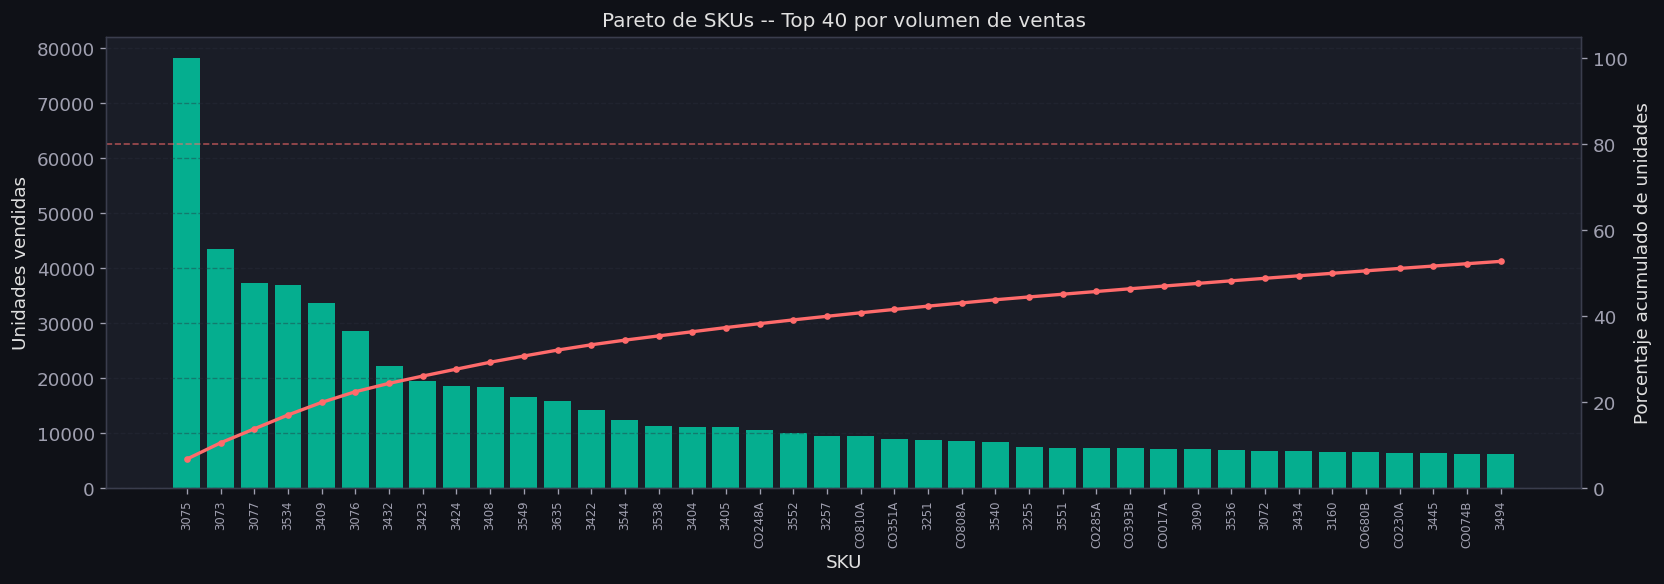

In [49]:
# -- Grafico Pareto ----------------------------------------------------------
top_n   = min(40, len(ventas_global))
df_plot = ventas_global.head(top_n)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(range(top_n), df_plot['UNIDADES'], color=PALETTE[0], alpha=0.8)
ax1.set_ylabel('Unidades vendidas')
ax1.set_xticks(range(top_n))
ax1.set_xticklabels(df_plot['CODIGO_SKU'], rotation=90, fontsize=7)
ax1.set_xlabel('SKU')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(range(top_n), df_plot['PCT_ACUM'], color=PALETTE[2], lw=2, marker='o', ms=3)
ax2.axhline(80, color=PALETTE[2], linestyle='--', lw=1, alpha=0.6)
ax2.set_ylabel('Porcentaje acumulado de unidades')
ax2.set_ylim(0, 105)

if n80 < top_n:
    ax1.axvline(n80 - 0.5, color=PALETTE[3], lw=1.5, ls='--')
    ax1.text(n80, ax1.get_ylim()[1] * 0.9,
             f'80%\n({n80} SKUs)', color=PALETTE[3], fontsize=9, ha='left')

plt.title(f'Pareto de SKUs -- Top {top_n} por volumen de ventas', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/dashboard/pareto_skus.png', dpi=300, bbox_inches='tight')
plt.show()


In [50]:
# -- Top 10 SKUs por pais ----------------------------------------------------
for pais in sorted(ventas_sku['PAIS'].unique()):
    df_p = (
        ventas_sku[ventas_sku['PAIS'] == pais]
        .sort_values('UNIDADES', ascending=False)
        .head(10)
    )
    print(f'\n=== Top 10 SKUs -- {pais} ===')
    print(df_p[['CODIGO_SKU', 'MODEL_NAME', 'BRAND', 'TIER', 'UNIDADES', 'TRANSAC']].to_string(index=False))



=== Top 10 SKUs -- NI ===
CODIGO_SKU                   MODEL_NAME   BRAND          TIER  UNIDADES  TRANSAC
      3075              KIT BLU Z4 BLUE     BLU FEATURE PHONE     78236    78236
      3073         KIT BLU Z4 BLACK/RED     BLU FEATURE PHONE     43448    43448
      3077              KIT BLU Z4 GRAY     BLU FEATURE PHONE     37322    37322
      3534      KIT ZTE BLADE A35 BLACK     ZTE         ENTRY     37047    37047
      3409  KIT ZTE BLADE A33 CORE BLUE     ZTE         ENTRY     33690    33690
      3076             KIT BLU Z4 GREEN     BLU FEATURE PHONE     28608    28608
      3432  KIT BLU Z4 MUSIC BLACK/BLUE     BLU FEATURE PHONE     22286    22286
      3423     KIT BMOBILE K391 BLUE DS BMOBILE FEATURE PHONE     19511    19511
      3424    KIT BMOBILE K391 BLACK DS BMOBILE FEATURE PHONE     18576    18576
      3408 KIT ZTE BLADE A33 CORE BLACK     ZTE         ENTRY     18346    18346

=== Top 10 SKUs -- PY ===
CODIGO_SKU MODEL_NAME BRAND TIER  UNIDADES  TRANSAC
   

## 8 · Revisión de PRECIO_UNITARIO

El campo PRECIO_UNITARIO fue calculado como COSTO / VALUE. Se verifica si el catalogo devices tiene un precio de referencia propio y se determina cual usar en el modelo.

In [51]:
# -- Comparar precio calculado vs catalogo -----------------------------------
ventas_precio = datos_filtrados[datos_filtrados['TIPO_TRANSACCION'] == 'SALES'].copy()

precio_referencia = (
    ventas_precio
    .groupby('CODIGO_SKU')['PRECIO_UNITARIO']
    .median()
    .reset_index()
    .rename(columns={'PRECIO_UNITARIO': 'PRECIO_MEDIANA'})
)

cols_precio = [c for c in devices.columns if 'PRECIO' in c.upper() or 'PRICE' in c.upper()]
print(f'Columnas de precio en catalogo devices: {cols_precio if cols_precio else "Ninguna -- se usara mediana historica"}')

print(f'\nRango PRECIO_UNITARIO calculado (COSTO/VALUE):')
print(ventas_precio['PRECIO_UNITARIO'].describe().round(2).to_string())

print(f'\nPrecio mediana por SKU (top 10 mas caros):')
print(precio_referencia.sort_values('PRECIO_MEDIANA', ascending=False).head(10).to_string(index=False))

print(f'\nConclusion: COSTO es el costo total de la linea y VALUE son las unidades.')
print('El calculo COSTO / VALUE es correcto como proxy de precio unitario.')
print('Se usara la mediana historica por SKU para normalizar outliers.')


Columnas de precio en catalogo devices: Ninguna -- se usara mediana historica

Rango PRECIO_UNITARIO calculado (COSTO/VALUE):
count    1023485.00
mean          98.34
std          185.74
min            1.04
25%           11.50
50%           45.88
75%          102.69
max         2149.45

Precio mediana por SKU (top 10 mas caros):
CODIGO_SKU  PRECIO_MEDIANA
      3525         2149.45
      3262         2018.02
      3441         2005.00
    CO048C         1842.77
      3263         1718.24
      3384         1678.06
      3385         1678.06
      3381         1677.83
      3382         1677.83
    CO495A         1558.75

Conclusion: COSTO es el costo total de la linea y VALUE son las unidades.
El calculo COSTO / VALUE es correcto como proxy de precio unitario.
Se usara la mediana historica por SKU para normalizar outliers.
